In [1]:
from google.colab import drive
import os
drive.mount('/content/gdrive')

working_dir = '/content/gdrive/MyDrive/calliope'
pretrained_model_dir= working_dir+ '/model_23-03-2026'
model_dir = working_dir + '/model_26-03-2026'
os.listdir(model_dir)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


['train_08-03-2026.csv',
 'y_pred.npy',
 'tokenizer',
 'model.pt',
 'calibrator.pt',
 'calib.csv',
 'train.csv',
 'test.csv',
 'distilbert.ipynb',
 'model_fp32.onnx.data',
 'model_fp32.onnx',
 'model_int8.onnx',
 'quantize_attempt_1.ipynb',
 'distilbert_onnx_fp32',
 'distilbert_int8',
 'bert.pt',
 'torch_model.pt',
 'quantize_attempt_2.ipynb',
 'test.ipynb',
 'eval_data.csv']

# Calliope: Evaluation

In this notebook we'll look at Calliope's performance on a test set. Let's first import the necessary libraries and the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, precision_score, recall_score, confusion_matrix
import math

In [3]:
eval_data = pd.read_csv(model_dir + '/eval_data.csv')
eval_data

,y_pred,y_test
0,4.382025,6.983534
1,4.538495,6.854085
2,5.480501,6.910213
3,5.806338,6.657054
4,5.958462,6.221749
...,...,...
20495,1.510783,0.602060
20496,0.792204,0.000000
20497,1.992794,0.000000
20498,1.215182,0.000000


The data contains the base-10 log of the view count for 20500 real videos (y_test), and the model prediction (y_pred). Let's first look at how the data is distributed:

In [4]:
eval_data.describe()

,y_pred,y_test
count,20500.000000,20500.000000
mean,2.675487,2.650197
std,1.068831,1.373394
min,0.515506,0.000000
25%,1.917594,1.740363
50%,2.508428,2.580925
75%,3.233088,3.297815
max,6.960904,8.165928


 The baseline model discussed in the previous notebook, which was trained and tested on LLM-generated data, had R$^2$ = 0.2. Let's evaluate R$^2$ for the full model (Calliope's prediction engine):

In [5]:
r2_score(eval_data['y_test'], eval_data['y_pred'])

0.6349897054654683

We can visualise the predictive power of the model by plotting the predictions against the ground truth:

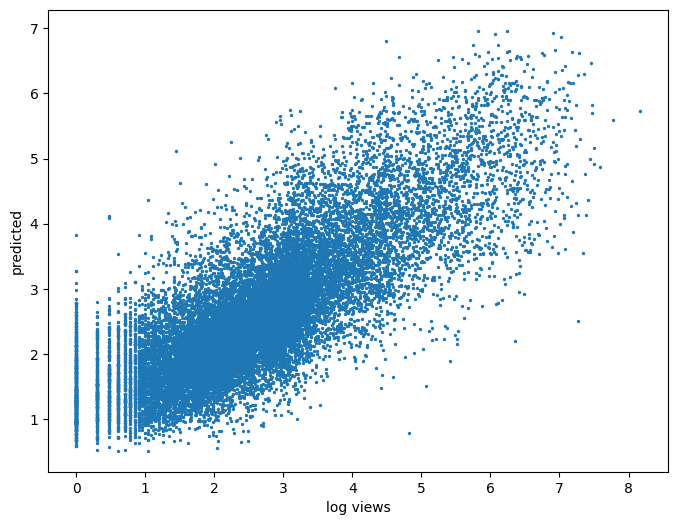

In [6]:
fig, ax = plt.subplots(figsize=(8,6))

ax.set_xlabel('log views')
ax.set_ylabel('predicted')
ax.scatter(eval_data['y_test'], eval_data['y_pred'], s=2)

Next, we will convert the regressor into a set of binary predictors: given a fixed threshold $T$, we can perform a division into two classes depending on whether the number of views is greater than or less than $T$. Let's determine the precision and recall of the predictors as $T$ is varied:

In [7]:
def get_pr(threshold):
  y_test = eval_data['y_test'] > threshold
  y_pred = eval_data['y_pred'] > threshold
  return precision_score(y_test, y_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0)

def get_confusion_matrix(threshold):
  y_test = eval_data['y_test'] > threshold
  y_pred = eval_data['y_pred'] > threshold
  cm = confusion_matrix(y_test, y_pred)
  return pd.DataFrame({f'predicted under 10^{threshold:.1f} views': cm[0,:],
                       f'predicted over 10^{threshold:.1f} views': cm[1,:]},
                      index=[f'under 10^{threshold:.1f} views', f'over 10^{threshold:.1f} views'])

In [8]:
thresholds = np.linspace(0, 9, 901)
pr = [get_pr(t) for t in thresholds]

p, r = zip(*pr)

We can plot these results:

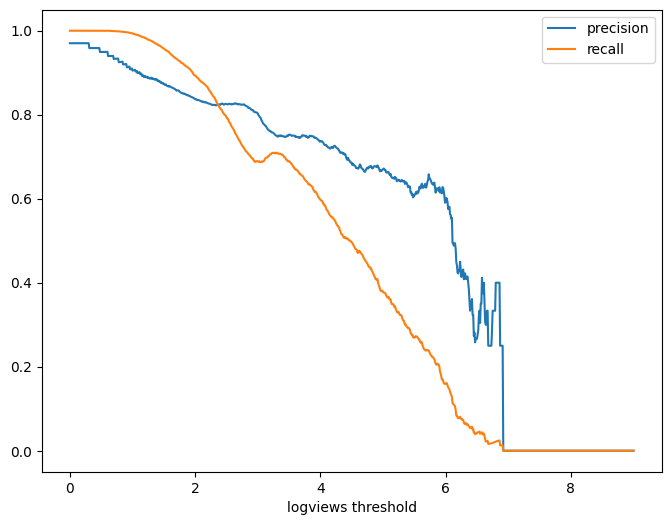

In [9]:
fig, ax = plt.subplots(figsize=(8,6))

ax.set_xlabel('logviews threshold')

ax.plot(thresholds, p, label='precision')
ax.plot(thresholds, r, label='recall')

ax.legend()

At the median view count, which is approximately $10^{2.5} \approx 320$ views, Calliope performs well.

In [10]:
get_pr(2.5)

(0.825, 0.7942164179104477)

When it comes to extremely highly viewed videos, Calliope performs significantly worse but still retains considerable predictive power.

In the context of virality, the threshold of 1M views is often discussed. Let's look at the confusion matrix, precision and recall of the binary classifier operating at this threshold:

In [11]:
get_confusion_matrix(6)

,predicted under 10^6.0 views,predicted over 10^6.0 views
under 10^6.0 views,19986,389
over 10^6.0 views,51,74


In [12]:
(eval_data['y_test']> 6).sum()/len(eval_data), (eval_data['y_pred'] > 6).sum()/len(eval_data)

(np.float64(0.022585365853658536), np.float64(0.006097560975609756))

In [13]:
get_pr(6)

(0.592, 0.15982721382289417)

At 2.3% of the dataset, it would be a significant challenge to both correctly label videos with over 1M views *and* correctly predict that videos will achieve this threshold. Calliope was able to identify 16% of videos with 1M views, and of the videos Calliope predicted would obtain over 1M views, 59% achieved this in reality.

